## 분류 모델

- 분류 : 범주를 예측하는 모델
- 종류 
  - 이진 분류 : 상승/하락, 스팸 여부, 연체 여부 등과 같이 두 가지 범주로 분류할 수 있는 경우. 
  - 다중 분류 : 섹터 예측, 신용 등급 등과 같이 여러 가지 범주로 분류할 수 있는 경우

> **이진 분류**가 지표가 명확하고 가장 많이 사용되는 형태

우리가 가지고 있는 데이터(시세)에서 `수익률`, `거래량 비율`, `이동평균대비`, `변동성` 데이터들로
상승(up)/하락(down)으로 분류할 수 있음! 

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, time_split, FEATURES, SEED

setup()
pd.set_option("display.width", 130)
 
df = build_dataset()
train, test, cutoff = time_split(df) 

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)

X_train, y_train = tr[FEATURES], tr["target_up"]
X_test, y_test = te[FEATURES], te["target_up"]

print(f" * 학습 {len(tr):,}행 ({tr['date'].min().date()} ~ {tr['date'].max().date()})")
print(f" * 테스트 {len(te):,}행 ({te['date'].min().date()} ~ {te['date'].max().date()})")

 * 학습 15,000행 (2023-10-24 ~ 2026-01-16)
 * 테스트 4,000행 (2026-01-19 ~ 2026-09-07)


## 분류 알고리즘(모델) 종류 (대표적인 6가지)
모든 알고리즘은 동일한 방식으로 사용할 수 있음.

```python
model = 어떤모델()

model.fit(X_train, y_train)
pred = model.predict(X_test)
score = model.score(X_test, y_test)
```

- 종류
  - LogisticRegression (로지스틱 회귀) : 선형 회귀 방식을 분류에 적용한 모델. 데이터가 어떤 범주에 속할 확률을 0과 1 사이의 값으로 예측
    - 스케일링이 필요하며, 속도가 빠름.
    - 결과 해석이 용이하지만 성능은 보통 수준임.
  - DecisionTree (의사결정나무) : 스무고개 하듯이 데이터의 특징을 기준으로 질문을 던져가며 데이터를 분류하는 직관적인 트리 구조의 모델.
    - 스케일링이 불필요하고, 속도가 빠름.
    - 모델 해석이 쉬운 편이나, 과적합되기 쉽기 때문에 단일 모델로는 성능이 비교적 낮음.
  - KNN (K-Nearest Neighbors, K-최근접 이웃) : 새로운 데이터를 예측할 때, 주변에 가장 가까이 있는 K개의 이웃 데이터들이 속한 범주를 다수결로 판별하는 방식.
    - 거리 기반으로 스케일링이 필수적임.
    - 학습은 없지만 예측 속도가 느리고, 해석은 제한적이며 성능은 보통 수준임.
  - RandomForest (랜덤 포레스트) : 여러 개의 의사결정나무를 만들고, 이들의 예측 결과를 취합하여 최종 결과를 도출하는 앙상블 기법.
    - 스케일링이 불필요하며 속도는 보통임.
    - 트리가 여러 개라 단일 트리에 비해 해석은 제한적이지만 성능이 매우 좋고 안정적임.
  - SVM (Support Vector Machine) : 클래스들을 구분하는 최적의 경계선을 찾는 알고리즘. 경계에서 가장 가까운 데이터와의 마진을 최대화함.
    - 스케일링이 필요하며 학습 및 예측 속도가 매우 느림.
    - 내부가 블랙박스 같아 모델 해석이 어렵지만, 데이터에 따라 매우 뛰어난 성능을 발휘하기도 함.
  - GradientBoosting (그래디언트 부스팅) : 이전 트리가 만든 예측의 오차를 다음 트리가 보완하는 방식으로, 여러 개의 트리를 순차적으로 학습시키는 앙상블 기법.
    - 스케일링이 불필요하며, 트리를 순차적으로 만들기 때문에 속도는 느림.
    - 해석은 제한적이나, 머신러닝 알고리즘 중 비교적 높은 수준의 성능을 보여줌.

#### 6개 한 장 정리

|모델|스케일링|속도|해석|성능|
|:--:|:--:|:--:|:--:|:--:|
|LogisticRegression|필요|빠름|쉬움|보통|
|DecisionTree|불필요|빠름|매우 쉬움|낮은 편 (과적합)|
|KNN|**필수**|예측 느림|제한적|보통|
|RandomForest|불필요|보통|제한적|매우 좋음|
|SVM|**필수**|매우 느림|어려움 (블랙박스)|데이터에 따라 뛰어남|
|GradientBoosting|불필요|느림|제한적|높음|

> **앙상블 구분** : RandomForest는 트리를 **동시에** 만들어 투표하고, GradientBoosting은 트리를 **순서대로** 만들며 앞 트리의 오차를 보완함.

In [ ]:
# 모델 별로 성능 비교

# 다른 모델 성능을 비교할 기준선을 만드는 분류기
from sklearn.dummy import DummyClassifier  

# 앙상블 모델. 여러 개의 알고리즘이 합쳐진 모델.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.linear_model import LogisticRegression  # 선형 모델
from sklearn.neighbors import KNeighborsClassifier  # KNN 모델
from sklearn.tree import DecisionTreeClassifier    # 의사결정나무
from sklearn.svm import SVC                       # SVM 모델

from sklearn.preprocessing import StandardScaler   # 각 피처의 평균을  0, 표준편차 1로 맞춰줌
from sklearn.pipeline import Pipeline             # 전처리 ~ 모델 학습 과정을 하나로 묶어주는 도구

# accuracy_score (정확도), f1_score (정밀도, 재현율 조화 평균) 
from sklearn.metrics import accuracy_score, f1_score



# 스케일링이 필요한 모델을 Pipeline 으로 묶어주기
def with_scaler(model):
    return Pipeline(
        [
            ("sc", StandardScaler()),
            ("m", model)
        ]
    )

# SVM => 데이터 수의 제곱에 비례해서 느려짐. 표본을 줄여서 사용.
SVM_N = 3000

# "모델명": (모델객체, 표본수변경여부)
models = {
    "DummyClassifier": (DummyClassifier(strategy="most_frequent"), False),
    "LogisticRegression": (with_scaler(LogisticRegression(max_iter=1000, random_state=SEED)), False),
    "DecisionTree(제한없음)": (DecisionTreeClassifier(random_state=SEED), False),
    "DecisionTree(제한)": (DecisionTreeClassifier(max_depth=5, random_state=SEED), False),
    "KNN(k=50)": (with_scaler(KNeighborsClassifier(n_neighbors=50)), False),
    "RandomForest": (RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1), False),
    "GradientBoosting": (GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED), False),
    "SVM (표본 3천개)": (with_scaler(SVC(random_state=SEED)), True),
}


# 결과(rows) -> {"모델": 모델명, "학습": score, "테스트": score, "f1": f1, "학습시간": 시간}
rows = []
for name, (model, small) in models.items():
    # small 값에 따라 표본 수 줄이기
    Xtr = X_train.iloc[:SVM_N] if small else X_train
    ytr = y_train.iloc[:SVM_N] if small else y_train

    t0 = time.perf_counter()
    model.fit(Xtr,ytr)
    fit_time = time.perf_counter() - t0         # 모델별 학습 시간 기록
    #예측
    pred = model.predict(X_test)

    rows.append({
        "모델": name,
        "학습": model.score(Xtr, ytr),
        "테스트": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred, zero_division=0),
        "학습시간": fit_time,
    })

result = pd.DataFrame(rows) 
print(result.round(4).to_string(index=False))   

                모델     학습    테스트     F1   학습시간
   DummyClassifier 0.5069 0.5175 0.0000 0.0132
LogisticRegression 0.5107 0.4805 0.3859 0.0085
DecisionTree(제한없음) 1.0000 0.5005 0.4893 0.1376
  DecisionTree(제한) 0.5219 0.4810 0.5245 0.0351
         KNN(k=50) 0.5672 0.5178 0.4708 0.0104
      RandomForest 0.6105 0.4932 0.4269 0.1645
  GradientBoosting 0.5987 0.4960 0.4434 2.0521
      SVM (표본 3천개) 0.5720 0.4915 0.3787 0.1289


## 분류 모델 성능 결과

- **기준 모델(DummyClassifier)**
  - 항상 다수 클래스로만 예측하는 모델. 이 몬델의 테스트 정확도(0.5175)가 성능 평가의 최소 기준선이
  됨.
  - 다른 머신러닝 모델들의 정확도가 이보다 낮게 나온다면, 그 모델들은 의미 있는 패턴을 찾지 못하고 있음.

- **정확도(Accuracy)와 F1 점수**
  - `Dummy` 는 정확도가 높은 편이지만, 한 가지로만 분류했기 떄문에 소수 클래스를 맞출 확률이 없어 F1
  점수가 **0.0000**임.
  - 반면에, `DecisionTree(제한)`는 정확도는 상대적으로 낮지만 F1 점수는 **0.5245**로 가장 높음.
  - 불균형하거나 정제되지 않은 데이터에서는 정확도만 보고 판단하기 보다, F1 점수 등 다른 지표를 함께
  확인해야 함.

- **트리의 과적합**
  - `DecisionTree(제한없음)`: 학습 정확도 1.0000 이라는 것은 학습 데이터를 100% 외웠다는 의미.
  테스트 결과와의 격차가 가장 크기 때문에 전형적인 과적합 상태를 보여줌. 제약(가지치기)의 필요성을 나타냄.

- **알고리즘별 연산 비용(학습 시간) 한계**
  - **GradientBoosting**: 학습 시간이 2초 이상이 걸림. 앞의 트리가 만든 오차를 뒤의 트리가 순차적으로 
  고쳐나가야 하기 때문에, 병렬 처리가 불가한 부스팅 알고리즘 특유의 느린속도를 보여줌.
  - **SVM** : 표본(데이터)을 전체의 1/5 수준으로 줄였는데도 0.14초나 걸림. 데이터 수의 제곱 이상으로
  연산량이 폭증하는 SVM의 단점을 확인할 수 있음.

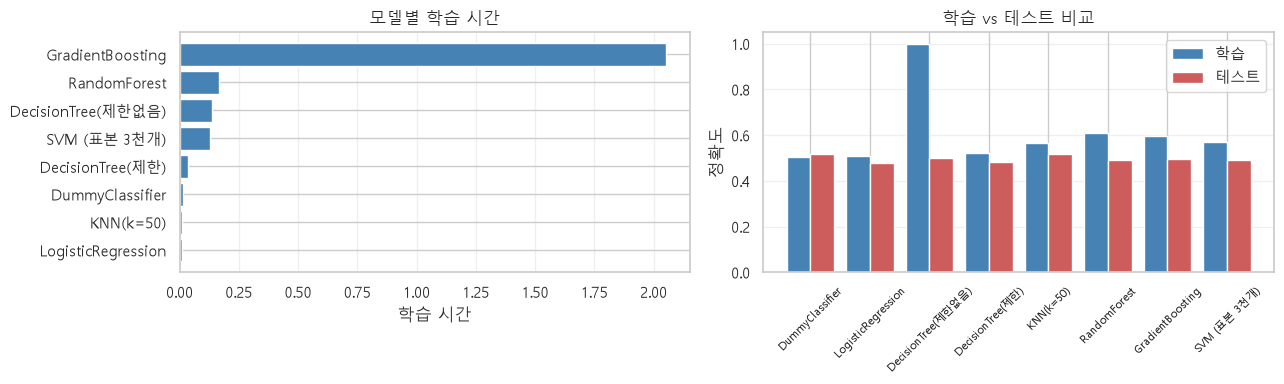

In [4]:
# 시각화하여 비교해보기

fig, axes = plt.subplots(1,2, figsize=(13,4))

# 학습 시간
r = result.sort_values("학습시간")

# barh : 가로 막대 그래프
axes[0].barh(r["모델"],r["학습시간"], color="steelblue")

axes[0].set_xlabel("학습 시간")
axes[0].set_title("모델별 학습 시간")
axes[0].grid(alpha=0.3, axis="x")

# 학습 vs 테스트 정확도 비교
x = np.arange(len(result))
axes[1].bar(x= x - 0.2, width=0.4, height=result["학습"], label="학습",color="steelblue")
axes[1].bar(x= x+ 0.2, width=0.4, height=result["테스트"], label="테스트",color="indianred")
# * x: 가로축 위치 조정 (동일한 그래프를 겹치지 않고 표시하기 위해 설정)
# * height : 막대 높이. 표현할 데이터 값.
# * width : 막대의 두께(너비)
axes[1].set_xticks(x) # x축 눈금의 기본 위치
axes[1].set_xticklabels(result["모델"], rotation=45, fontsize=8)   # 숫자 대신 모델 이름

axes[1].set_ylabel("정확도")
axes[1].set_title("학습 vs 테스트 비교")
axes[1].legend()                    # "학습", "테스트" 범례 표시
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()